# Solar Filament Segmentation Challenge 2026

## 1. Competition Introduction & Data Testbed

* **Core Phenomenon**: Solar filaments are dense, cold plasma structures suspended by magnetic field lines in the solar corona. They are the catalyst for space weather eruptions like Coronal Mass Ejections (CMEs), which can catastrophically **damage Earth's power grids, GPS, and communication infrastructure**.
* **MAGFiLO Dataset**: Standing for Manually Annotated GONG Filaments from H-Alpha Observations, this dataset functions as the official benchmarking testbed.
* **Data Constraints**: Models must exclusively utilize the provided H-alpha test images for inference and are **strictly forbidden from training with any outside ground-truth metadata**.

## 2. Evaluation Rubric & Metrics
The final score combines a quantitative performance review and a qualitative pipeline assessment:

* **Quantitative Comparison (70%)**: Evaluates overlapping pixel accuracy, geometric distribution, error handling, and runtime mechanics:
* **Panoptic Quality (PQ)**: The primary leaderboard ranking metric, calculating combined instance detection and segmentation overlap.
   * **Mean Dice Score & IoU**: Tracked via `torchmetrics.segmentation.DiceScore` to evaluate overlap accuracy.
   * **Structural Mappings**: Tracks distribution of one-to-many (fragmentation) and many-to-one (over-merging) prediction faults.
* **Qualitative Evaluation (30%)**: Assesses end-to-end pipeline descriptions, structural morphology accuracy on H-alpha imagery, and code modularity/documentation.
* **Scoreboard Splits**: The public scoreboard tracks the mean Dice score for **~50% of the test set images**. The remaining **50% stays hidden** for internal organizer validation.

## 3. Technical Implementation Challenges
Algorithms must be engineered to overcome three distinct physical and visual obstacles:

* **Fine-scale Structures**: Difficulty capturing **barbs** (thin, thread-like filament extensions) which dictate the underlying magnetic field orientation.
* **Background Noise**: Differentiating dark filament shapes from solar background artifacts, sunspots, and ground-based observatory imaging noise.
* **Structural Continuity**: Preventing models from over-segmenting continuous structures into broken pieces ("islands") or over-merging independent adjacent structures.

## 4. Submission Specifications

* **File Format**: A single **CSV file** detailing the entire test set.
* Required Columns:
* `filament_id`: A unique ID string appended with a distinct tail string marker per instance (e.g., `_1`, `_2`, `_3`) for images hosting multiple filaments.
   * `segmentation_rle`: Unquoted **Run-Length Encoded (RLE) Counts** representing the segmentation mask.
* **Dimension Guidelines**: All processing masks map to a fixed resolution layout of **2048 x 2048 pixels**. Predictions are evaluated based on coordinate overlap rather than index order.
* **Conversion Tools**: Competitors must format masks to RLE counts via the pycocotools Python library (`annToMask`, `decodeMask`, `encodeMask`).

## 5. Prizes & Post-Competition Requirements
A total prize pool of up to **$3,000** will be divided among the top **3 teams**. Individual prize allocations are calculated using a weighted temperature formula (T=2.0) based on the evaluation rubric scores.
Winners will be announced at **IEEE BigData 2026 (December 14–17, 2026, Phoenix, AZ)** contingent on meeting the following requirements:

* **Open-Access Code Release**: A publicly accessible Git repository hosting all scripts, weights, and configurations must be opened immediately at competition close. The source code must seamlessly reproduce the submitted leaderboard results.
* **Technical Report**: Submission of a concise technical layout documenting the preprocessing, architecture, training configurations, and post-processing strategies.
* **Administrative Setup**: Compliance with AURA onboarding vendors, providing direct banking information capable of receiving transfers from U.S. financial institutions.





# Data and Directory Structure

## 1. Directory Structure & Data Constraints
When unzipped, the `MAGFiLO_1.0_Kaggle_2026/` directory contains the following structural layout:

* **train/**: Contains `train_images/` and the master annotation file `MAGFiLO_1.0_Annotations_kaggle2026_train.json`.
* **test/**: Contains `test_images/` used exclusively for model inference. No outside ground-truth metadata can be applied during training.

## 2. Image Properties & Naming Convention

* **Format**: Custom solar physics FITS files have been converted into standard **8-bit grayscale JPEG images** with a **fixed resolution of 2048 x 2048 pixels**. They **must be processed purely as grayscale (not multi-channel color/RGB)**.
* **Filename Metadata Syntax**: Coded as `<YYYYMMDDHHMMSSII>.jpeg` where II denotes the ground-based observatory station.
  * Example: `20260901165702Bh.jpeg` marks a capture on Sept 1, 2026, at 16:57:02 by the **Big Bear (Bh)** Solar Observatory.
* **Annotator Inter-Variability**: Multiple expert annotators independently reviewed the same raw files. If the same image features two distinct string prefixes (e.g., `010101-...` and `010102-...`), you should **treat them simply as separate, independent training samples**.

## 3. JSON COCO-Style Annotation Anatomy

The training annotations use the standardized COCO data format profile, making them fully compatible with the `pycocotools` framework.

### `image` Node Fields

* `id`: A unique string merging the annotator's batch ID and the target filename (e.g., `010401-20160920230134Lh`).
* `file_name`: String file path pointer mapping back to the images folder.

### `annotation` Node Fields

* `id`: A unique UUID string identifying individual filament entries.
* `image_id`: String mapping directly back to the image["id"].
* `category_id`: Integer tracking structural classification boundaries.
* `segmentation`: A list containing **exactly one single-piece polygon** mapped as a sequence of vertex coordinates: `[x0, y0, x1, y1, ..., xn-1, yn-1]`.
* `spine`: A contiguous coordinate path charting the primary structural "backbone" of the solar filament.
* `bbox`: Four-element pixel coordinates measuring `[x, y, width, height]` from the top-left corner.
* `iscrowd`: Always set to 0, explicitly dictating that no multi-filament blending clusters exist.

### `categories` Reference Map

Filaments are categorically grouped into four distinct target states based on structural morphology:

* `1`: "Left"
* `2`: "Right"
* `3`: "Unidentifiable"
* `4`: "Ambiguous"

## 4. Technical Submission & Validation Strategy

* **Format Specification**: The output CSV demands a `filament_id` alongside a `segmentation_rle` column populated by unquoted **Run-Length Encoded (RLE)** Counts.
* **Instance Splitting**: If an algorithm detects 3 isolated filaments in an image file, the final CSV must contain 3 rows uniquely designated with incremental trailing tags (e.g., `_1`, `_2`, `_3`).
* **Evaluation Targets**: Submissions are checked using **Panoptic Quality (PQ)** and the **Dice Score** via coordinate overlap matching. **Fragmented networks ("islands") or over-merged structures are heavily penalized**.
* **Winner Verification**: Top-3 payouts (from a total pool of **$3,000**) require open-sourcing the solution under an OSI-approved license alongside a detailed technical pipeline report at **IEEE BigData 2026**.


# 2. Imports, reproducibility, and paths

Only libraries needed for tabular, image, and plotting EDA are imported. TensorFlow and model-specific packages are intentionally not initialized here, which keeps data inspection lightweight.

In [ ]:
# =============================================
# 2. Imports, reproducibility, and paths
# =============================================
from collections import Counter
from datetime import datetime
from importlib import metadata
from typing import cast
import json
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
from matplotlib.patches import Polygon as PolygonPatch
from PIL import Image, ImageDraw

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_SEED = 10
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Set DATA_ROOT explicitly if the automatic search does not match your environment.
# Kaggle example:
# DATA_ROOT = Path("/kaggle/input/filament-segmentation-2026/MAGFilo_1.0_Kaggle_2026")
DATA_ROOT = Path("D:/filament-segmentation-2026/MAGFilo_1.0_Kaggle_2026")

TRAIN_DIR = DATA_ROOT / "train"
TRAIN_IMAGES_DIR = TRAIN_DIR / "train_images"
TEST_IMAGES_DIR = DATA_ROOT / "test" / "test_images"
ANNOTATION_PATH = TRAIN_DIR / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"

# Constants for dataset dimensions
IMAGE_WIDTH = 2048
IMAGE_HEIGHT = 2048
TOTAL_PIXELS = IMAGE_WIDTH * IMAGE_HEIGHT

INTENSITY_SAMPLE_STEP = 8
FILENAME_PATTERN = re.compile(r"^(?P<timestamp>\d{14})(?P<station>[A-Za-z]{2})\.(?P<extension>jpe?g)$", re.IGNORECASE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", palette="muted", context="notebook")

print(f"Data root: {DATA_ROOT}")
print(f"Random seed: {RANDOM_SEED}")
for package in ["numpy", "pandas", "matplotlib", "seaborn", "Pillow"]:
    try:
        print(f"{package}: {metadata.version(package)}")
    except metadata.PackageNotFoundError:
        print(f"{package}: version unavailable")

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {DATA_ROOT}. Set DATA_ROOT to the folder containing train/ and test/."
    )
for required_path in [TRAIN_IMAGES_DIR, TEST_IMAGES_DIR, ANNOTATION_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f"Required dataset path not found: {required_path}")

Data root: D:\filament-segmentation-2026\MAGFilo_1.0_Kaggle_2026
Random seed: 10
numpy: 2.5.3
pandas: 3.0.6
matplotlib: 3.11.2
seaborn: 0.13.2
Pillow: 12.3.0


## 2.1. Describe the directory structure

Inventory the immediate contents of each split and count image files. The recursive summary is useful for spotting unexpected files or misplaced annotations.

In [3]:
# =============================================
# 2.1. Directory inventory
# =============================================
def describe_directory(root: Path) -> list[dict]:
    """Return one summary row for each directory under root."""
    rows = []
    for directory in [root, *sorted(p for p in root.rglob("*") if p.is_dir())]:
        files = [p for p in directory.iterdir() if p.is_file()]
        rows.append({
            "relative_path": directory.relative_to(root).as_posix() or ".",
            "file_count": len(files),
            "directory_count": sum(p.is_dir() for p in directory.iterdir()),
            "size_mb": sum(p.stat().st_size for p in files) / 1024**2,
        })
    return rows

directory_summary = pd.DataFrame(describe_directory(DATA_ROOT))
display(directory_summary)

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
train_files = sorted(p for p in TRAIN_IMAGES_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)
test_files = sorted(p for p in TEST_IMAGES_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)

split_summary = pd.DataFrame([
    {"split": "train", "image_files": len(train_files), "directory": str(TRAIN_IMAGES_DIR)},
    {"split": "test", "image_files": len(test_files), "directory": str(TEST_IMAGES_DIR)},
])
split_ratio = len(train_files) / (len(train_files) + len(test_files)) if (len(train_files) + len(test_files)) > 0 else 0
display(split_summary)
print(f"Total supplied JPEG/image files: {len(train_files) + len(test_files):,}")
print(f"Train/test split ratio: {split_ratio:.2%} train, {1 - split_ratio:.2%} test")

,relative_path,file_count,directory_count,size_mb
0,.,0,2,0.0000
1,test,0,1,0.0000
2,test/test_images,180,0,136.3620
3,train,1,1,46.3645
4,train/train_images,707,0,533.4578


,split,image_files,directory
0,train,707,D:\filament-segmentation-2026\MAGFilo_1.0_Kagg...
1,test,180,D:\filament-segmentation-2026\MAGFilo_1.0_Kagg...


Total supplied JPEG/image files: 887
Train/test split ratio: 79.71% train, 20.29% test


# 3. Load and inspect the COCO-style annotations

Load the annotation JSON and inspect its top-level metadata, categories, and record counts before deriving any labels.

In [4]:
# =============================================
# 3. Load annotations and create tables
# =============================================
with ANNOTATION_PATH.open("r", encoding="utf-8") as file:
    annotations_data = json.load(file)

required_top_level_keys = {"images", "annotations", "categories"}
missing_keys = required_top_level_keys - annotations_data.keys()
if missing_keys:
    raise KeyError(f"Annotation JSON is missing required keys: {sorted(missing_keys)}")

images_df = pd.DataFrame(annotations_data["images"])
annotations_df = pd.DataFrame(annotations_data["annotations"])
categories_df = pd.DataFrame(annotations_data["categories"])
category_name_by_id = categories_df.set_index("id")["name"].to_dict()

print("Top-level keys:", list(annotations_data.keys()))
print("Dataset info:")
display(pd.Series(annotations_data.get("info", {}), name="value").to_frame())
print("Categories:")
display(categories_df)
print("Record counts:")
display(pd.DataFrame([
    {"record_type": "image records in JSON", "count": len(images_df)},
    {"record_type": "unique image filenames in JSON", "count": images_df["file_name"].nunique()},
    {"record_type": "annotation instances", "count": len(annotations_df)},
    {"record_type": "physical training image files", "count": len(train_files)},
]))

Top-level keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Dataset info:


,value
description,MLEcoFi 2024 Dataset - V1.0
url,https://www.mlecofi.net/
version,1.0
year,2024
contributor,MLEcoFi Team
date_created,2024-07-15
team,Earth-Space AI Research Lab (www.esairlab.com)
collaborators,"[National Solar Observatory, Georgia State Uni..."
date_updated,2026-06-01


Categories:


,supercategory,id,name
0,filament,1,Left
1,filament,2,Right
2,filament,3,Unidentifiable
3,filament,4,Ambiguous


Record counts:


,record_type,count
0,image records in JSON,1154
1,unique image filenames in JSON,707
2,annotation instances,8199
3,physical training image files,707


## 3.1. Annotation schema and missingness

Review field availability, data types, null counts, and sample rows. Polygon and spine values are nested arrays, so those fields are summarized as present/absent rather than expanded into hundreds of coordinate columns.

In [5]:
# =============================================
# 3.1. Schema and preview
# =============================================
def schema_summary(frame: pd.DataFrame) -> pd.DataFrame:
    unique_counts = {}
    for col in frame.columns:
        try:
            unique_counts[col] = frame[col].nunique(dropna=True)
        except TypeError:
            unique_counts[col] = frame[col].astype(str).nunique(dropna=True)

    return pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "missing_values": frame.isna().sum(),
        "missing_percent": frame.isna().mean().mul(100),
        "unique_values": pd.Series(unique_counts),
    }).rename_axis("column").reset_index()

print("Image record schema")
display(schema_summary(images_df))
print("Annotation schema")
display(schema_summary(annotations_df))
print("Image record examples")
display(images_df.head(5))
print("Annotation examples (nested geometry shortened)")
annotation_preview = annotations_df.drop(columns=["segmentation", "spine"], errors="ignore").head(5)
display(annotation_preview)
print("Geometry presence:")
display(pd.DataFrame({
    "geometry_field": ["segmentation", "spine", "bbox", "area"],
    "present_count": [
        annotations_df.get("segmentation", pd.Series(dtype=object)).notna().sum(),
        annotations_df.get("spine", pd.Series(dtype=object)).notna().sum(),
        annotations_df.get("bbox", pd.Series(dtype=object)).notna().sum(),
        annotations_df.get("area", pd.Series(dtype=object)).notna().sum(),
    ],
}))

Image record schema


,column,dtype,missing_values,missing_percent,unique_values
0,license,int64,0,0.0000,1
1,file_name,str,0,0.0000,707
2,url,str,0,0.0000,707
3,height,int64,0,0.0000,1
4,width,int64,0,0.0000,1
5,date_captured,str,0,0.0000,707
6,id,str,0,0.0000,1154


Annotation schema


,column,dtype,missing_values,missing_percent,unique_values
0,segmentation,object,0,0.0000,8199
1,area,float64,0,0.0000,3702
2,iscrowd,int64,0,0.0000,1
3,spine,object,0,0.0000,8196
4,image_id,str,0,0.0000,1154
5,bbox,object,0,0.0000,8199
6,category_id,int64,0,0.0000,3
7,id,str,0,0.0000,8199


Image record examples


,license,file_name,url,height,width,date_captured,id
0,1,20140609195854Bh.jpeg,https://gong2.nso.edu/HA/hag/201406/20140609/2...,2048,2048,2014-06-09 19:58:54,040301-20140609195854Bh
1,1,20111116063134Lh.jpeg,https://gong2.nso.edu/HA/hag/201111/20111116/2...,2048,2048,2011-11-16 06:31:34,050103-20111116063134Lh
2,1,20111116063134Lh.jpeg,https://gong2.nso.edu/HA/hag/201111/20111116/2...,2048,2048,2011-11-16 06:31:34,050102-20111116063134Lh
3,1,20111116063134Lh.jpeg,https://gong2.nso.edu/HA/hag/201111/20111116/2...,2048,2048,2011-11-16 06:31:34,050101-20111116063134Lh
4,1,20130725122934Ch.jpeg,https://gong2.nso.edu/HA/hag/201307/20130725/2...,2048,2048,2013-07-25 12:29:34,030101-20130725122934Ch


Annotation examples (nested geometry shortened)


,area,iscrowd,image_id,bbox,category_id,id
0,750.0000,0,040301-20140609195854Bh,"[388.4121, 799.966, 92.52639999999997, 52.4850...",2,d7fd9cdb-3f34-4dfc-a1fa-c1fd25110a98
1,"1,060.0000",0,040301-20140609195854Bh,"[427.3645, 1310.312, 96.6123, 46.15890000000013]",3,ca65251f-f7c8-4553-ad55-ad0f06272782
2,"1,381.0000",0,040301-20140609195854Bh,"[753.6963, 576.3292, 28.943200000000047, 145.3...",1,7b301b5d-fe5d-4b4d-b0b7-41b0f8cabeec
3,719.0000,0,040301-20140609195854Bh,"[1567.404, 654.9481, 26.704500000000053, 96.05...",2,184911bf-d671-4a08-bc84-6f5fb7ce5277
4,289.0000,0,040301-20140609195854Bh,"[1558.4171, 589.3484, 21.48590000000013, 40.87...",3,67dcd25e-ed1e-4565-960e-d653c9a905ab


Geometry presence:


,geometry_field,present_count
0,segmentation,8199
1,spine,8199
2,bbox,8199
3,area,8199


## 3.2. Check record IDs, references, and file coverage

These checks distinguish annotation-record integrity from physical-file coverage. A repeated `file_name` is reported explicitly and is not treated as an accidental duplicate by itself: the JSON image IDs may represent different annotation records for the same source pixels.

In [6]:
# =============================================
# 3.2. Integrity and file coverage
# =============================================
image_ids = set(images_df["id"])
annotation_image_ids = set(annotations_df["image_id"])
image_filenames = set(images_df["file_name"])
train_filenames = {path.name for path in train_files}
test_filenames = {path.name for path in test_files}

duplicate_image_records = images_df[images_df["file_name"].duplicated(keep=False)].copy()
duplicate_file_summary = (
    images_df.groupby("file_name", as_index=False)
    .agg(image_record_count=("id", "nunique"), image_ids=("id", lambda values: ", ".join(map(str, values))))
    .query("image_record_count > 1")
    .sort_values("image_record_count", ascending=False)
    .reset_index(drop=True)
)

integrity_summary = pd.DataFrame([
    {"check": "image record IDs unique", "result": images_df["id"].is_unique, "detail": f"{images_df['id'].nunique():,} unique / {len(images_df):,}"},
    {"check": "annotation IDs unique", "result": annotations_df["id"].is_unique, "detail": f"{annotations_df['id'].nunique():,} unique / {len(annotations_df):,}"},
    {"check": "all annotations reference a known image_id", "result": annotation_image_ids <= image_ids, "detail": f"{len(annotation_image_ids - image_ids):,} unknown image IDs"},
    {"check": "all JSON filenames have a training JPEG", "result": image_filenames <= train_filenames, "detail": f"{len(image_filenames - train_filenames):,} missing files"},
    {"check": "training files represented in JSON", "result": train_filenames <= image_filenames, "detail": f"{len(train_filenames - image_filenames):,} unreferenced training files"},
    {"check": "training/test filename overlap", "result": not (train_filenames & test_filenames), "detail": f"{len(train_filenames & test_filenames):,} overlapping names"},
])
display(integrity_summary)
print(f"JSON image records: {len(images_df):,}; distinct filenames: {images_df['file_name'].nunique():,}")
print(f"Repeated filenames: {len(duplicate_file_summary):,}; extra records beyond one per filename: {len(images_df) - images_df['file_name'].nunique():,}")
display(duplicate_file_summary.head(15))

,check,result,detail
0,image record IDs unique,True,"1,154 unique / 1,154"
1,annotation IDs unique,True,"8,199 unique / 8,199"
2,all annotations reference a known image_id,True,0 unknown image IDs
3,all JSON filenames have a training JPEG,True,0 missing files
4,training files represented in JSON,True,0 unreferenced training files
5,training/test filename overlap,True,0 overlapping names


JSON image records: 1,154; distinct filenames: 707
Repeated filenames: 296; extra records beyond one per filename: 447


,file_name,image_record_count,image_ids
0,20110306082634Lh.jpeg,3,"010403-20110306082634Lh, 010401-20110306082634..."
1,20220721185332Bh.jpeg,3,"010403-20220721185332Bh, 010401-20220721185332..."
2,20110322005814Mh.jpeg,3,"050101-20110322005814Mh, 050102-20110322005814..."
3,20110128174814Mh.jpeg,3,"010402-20110128174814Mh, 010401-20110128174814..."
4,20110203082634Lh.jpeg,3,"010102-20110203082634Lh, 010101-20110203082634..."
5,20210223222830Ch.jpeg,3,"010401-20210223222830Ch, 010402-20210223222830..."
6,20210817165030Mh.jpeg,3,"010403-20210817165030Mh, 010402-20210817165030..."
7,20211225025850Uh.jpeg,3,"010203-20211225025850Uh, 010201-20211225025850..."
8,20220328143550Bh.jpeg,3,"050103-20220328143550Bh, 050101-20220328143550..."
9,20220622205632Bh.jpeg,3,"050103-20220622205632Bh, 050102-20220622205632..."


## Key interpretation

COCO IDs are annotation-record identifiers, while `file_name` identifies the actual pixels. Repeated filenames can carry separate annotations for the same image. When creating a validation split, group on the filename (or another source-image key) to keep identical pixels on one side of the split. The integrity table also makes any missing or unreferenced files visible instead of assuming the package is complete.

# 4. Explore filament instance labels

We are going to count instances by category, and then count annotated instances per COCO image record and per physical filename. The record-level and filename-level views answer different questions when annotations are repeated.

## 4.1. Map Categories and count instances

This section connect numerical category IDs to their actual names and calculates the total counts and percentages of each category.

In [ ]:
# =============================================
# 4.1. Map Categories and count instances
# =============================================

annotations_df["category_name"] = annotations_df["category_id"].map(category_name_by_id).fillna("Unknown")

category_counts = (
    annotations_df.groupby(["category_id", "category_name"], dropna=False)
    .size().rename("instances").reset_index()
)

category_counts["instance_percent"] = category_counts["instances"].div(len(annotations_df)).mul(100)

category_counts = categories_df[["id", "name"]].rename(columns={"id": "category_id", "name": "category_name"}).merge(
    category_counts, on=["category_id", "category_name"], how="left"
).fillna({"instances": 0, "instance_percent": 0})

print("Category distribution table:")
display(category_counts.sort_values("category_id"))

Category distribution table:


,category_id,category_name,instances,instance_percent
0,1,Left,"2,535.0000",30.9184
1,2,Right,"2,590.0000",31.5892
2,3,Unidentifiable,"3,074.0000",37.4924
3,4,Ambiguous,0.0000,0.0000


## 4.2. Plot Category Distribution

Create a simple bar chart visualizing how many instances exist per category.



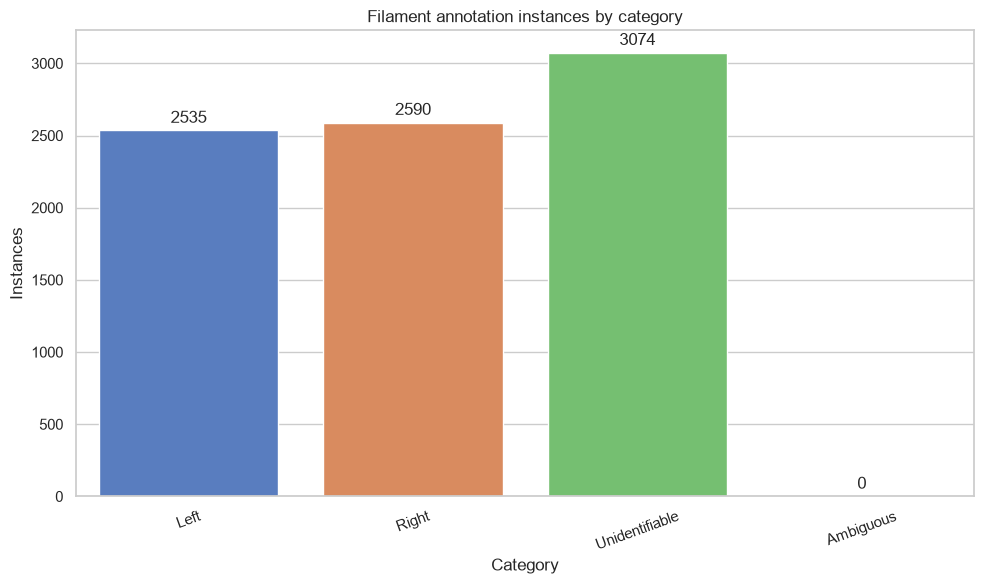

In [13]:
# =============================================
# 4.2. Plot Category Distribution
# =============================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=category_counts,
    x="category_name",
    y="instances",
    hue="category_name",
    legend=False,
    ax=ax,
)

ax.set(
    title="Filament annotation instances by category",
    xlabel="Category",
    ylabel="Instances",
)
ax.tick_params(axis="x", rotation=20)

for container in ax.containers:
    ax.bar_label(
        cast(BarContainer, container), fmt="%d", label_type="edge", padding=3
    )

plt.tight_layout()
plt.show()

Ambiguous filaments are 0, and Unidentifiable filaments are 3074(largest). Left and Right filaments are similar in count(2535, 2590).

## 4.3. Count instances per Image Record

This section counts how many annotations live inside every registered COCO image entry, even if that image contains zero annotations.

In [14]:
# =============================================
# 4.3. Count instances per Image Record
# =============================================

instances_per_image_record = annotations_df.groupby("image_id").size().rename("instance_count").reset_index()

record_counts = images_df[["id", "file_name"]].merge(
    instances_per_image_record, left_on="id", right_on="image_id", how="left"
).drop(columns="image_id")
record_counts["instance_count"] = record_counts["instance_count"].fillna(0).astype(int)

print("Descriptive statistics: Instances per COCO image record")
display(record_counts["instance_count"].describe().to_frame().T)



Descriptive statistics: Instances per COCO image record


,count,mean,std,min,25%,50%,75%,max
instance_count,"1,154.0000",7.1049,4.3755,1.0000,4.0000,7.0000,10.0000,26.0000


## 4.4. Pool Instances by Physical Filename

Sometimes multiple records reference the same physical file. This step groups the metrics by the actual string filename.

In [15]:
# =============================================
# 4.4. Pool Instances by Physical Filename
# =============================================
filename_counts = record_counts.groupby("file_name", as_index=False).agg(
    annotation_records=("id", "nunique"), 
    total_instances_across_records=("instance_count", "sum"),
    min_instances_per_record=("instance_count", "min"), 
    max_instances_per_record=("instance_count", "max")
)

print("Descriptive statistics: Records pooled by physical filename")
display(filename_counts[["total_instances_across_records", "annotation_records"]].describe())


Descriptive statistics: Records pooled by physical filename


,total_instances_across_records,annotation_records
count,707.0000,707.0000
mean,11.5969,1.6322
std,8.8651,0.8128
min,1.0000,1.0000
25%,5.0000,1.0000
50%,9.0000,1.0000
75%,15.0000,2.0000
max,58.0000,3.0000


## 4.5. Plot Instance Histogram

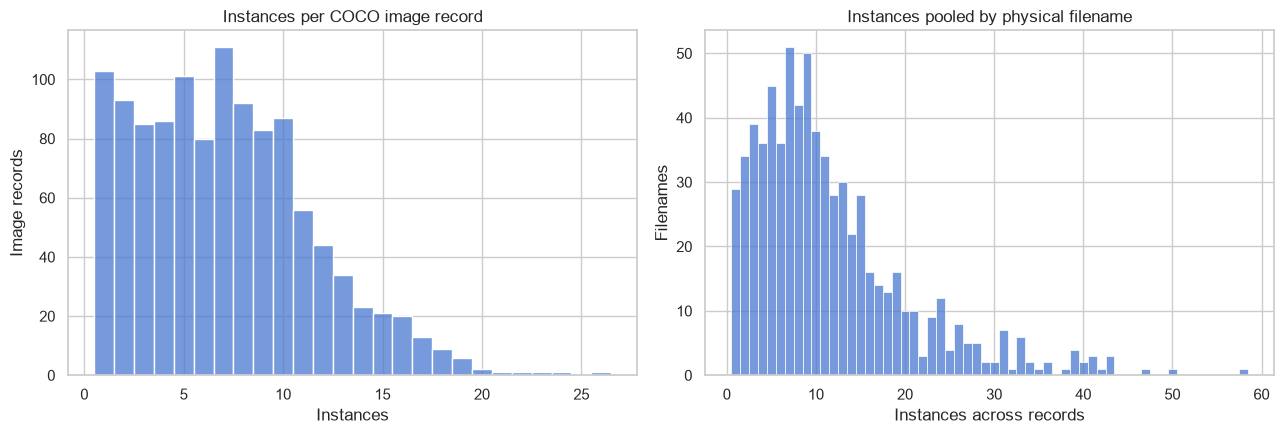

In [18]:
# =============================================
# 4.5. Plot Instance Histogram
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left Plot: Explicitly assign the Series to x
sns.histplot(x=record_counts["instance_count"], discrete=True, ax=axes[0])
axes[0].set(
    title="Instances per COCO image record",
    xlabel="Instances",
    ylabel="Image records",
)

sns.histplot(
    data=filename_counts, 
    x="total_instances_across_records", 
    discrete=True, 
    ax=axes[1]
)
axes[1].set(
    title="Instances pooled by physical filename",
    xlabel="Instances across records",
    ylabel="Filenames",
)
plt.tight_layout()
plt.show()


# 5. Annotation geometry and quality checks

Summarize polygon complexity, spine length, bounding-box size, and area relative to the image. The checks below validate coordinate ranges using each record's declared width and height. A polygon is considered structurally usable when it has at least three coordinate pairs and an even number of scalar coordinates.

## 5.1. Define Feature Extractor Function

This function takes an individual raw annotation dictionary, calculates basic metrics for polygons, spines, and bounding boxes, and returns them.
python

In [26]:
# =============================================
# 5.1. Define Feature Extractor Function
# =============================================

def geometry_features(annotation: dict) -> dict:
    # 1. Safely extract nested geometric sequences
    polygons = annotation.get("segmentation") or []
    # If standard COCO, polygons is a list of lists. We grab the first one.
    polygon = polygons[0] if polygons and isinstance(polygons[0], list) else []
    spine = annotation.get("spine") or []
    bbox = annotation.get("bbox") or []
    
    # 2. Slice standard COCO flat arrays: [x1, y1, x2, y2...] 
    coordinates = np.asarray(polygon, dtype=float)
    spine_coordinates = np.asarray(spine, dtype=float)
    x, y = coordinates[0::2], coordinates[1::2]
    spine_x, spine_y = spine_coordinates[0::2], spine_coordinates[1::2]
    
    # 3. Calculate Euclidean path length of the spine
    if len(spine_x) > 1:
        spine_length = np.sqrt(np.diff(spine_x) ** 2 + np.diff(spine_y) ** 2).sum()
    else:
        spine_length = np.nan
        
    # 4. Package geometric metrics
    return {
        "polygon_count": len(polygons),
        "polygon_vertices": len(coordinates) // 2,
        "polygon_even_coordinate_count": len(coordinates) % 2 == 0,
        "polygon_has_three_vertices": len(coordinates) >= 6,
        "polygon_min_x": x.min() if len(x) else np.nan,
        "polygon_max_x": x.max() if len(x) else np.nan,
        "polygon_min_y": y.min() if len(y) else np.nan,
        "polygon_max_y": y.max() if len(y) else np.nan,
        "spine_points": len(spine_coordinates) // 2,
        "spine_length_px": spine_length,
        "bbox_width": bbox[2] if len(bbox) == 4 else np.nan,
        "bbox_height": bbox[3] if len(bbox) == 4 else np.nan,
        "bbox_area": bbox[2] * bbox[3] if len(bbox) == 4 else np.nan,
    }


## 5.2. Build DataFrame of Features

Since images are 2048 x 2,048 pixels, We can calculate the area of each polygon and bounding box as a percentage of the total image area. The spine length is calculated as the sum of the Euclidean distances between consecutive spine points.

In [28]:


# 1. Parse features from the raw JSON structure
geometry_df = pd.DataFrame([geometry_features(row) for row in annotations_data["annotations"]])

# 2. Side-by-side join with existing tabular annotations
annotation_geometry = pd.concat([annotations_df.reset_index(drop=True), geometry_df], axis=1)

# 3. Add static dimensions for tracking reference
annotation_geometry["declared_image_width"] = IMAGE_WIDTH
annotation_geometry["declared_image_height"] = IMAGE_HEIGHT

# 4. Calculate box coverage relative to the constant image area
annotation_geometry["bbox_area_fraction"] = annotation_geometry["bbox_area"] / TOTAL_PIXELS

# 5. Compute boolean flag identifying if coordinates spill outside the 2048x2048 canvas borders
annotation_geometry["polygon_in_bounds"] = (
    (annotation_geometry["polygon_min_x"] >= 0)
    & (annotation_geometry["polygon_min_y"] >= 0)
    & (annotation_geometry["polygon_max_x"] <= IMAGE_WIDTH)
    & (annotation_geometry["polygon_max_y"] <= IMAGE_HEIGHT)
)


## 5.3. Display Statistical Summary and Integrity Checks

This isolates the numeric profiling from the plotting so you can review metrics table-by-table.

In [29]:
# =============================================
# 5.3. Display Statistical Summary and Integrity Checks
# =============================================
print("--- Geometric Property Distributions ---")
geometry_summary = annotation_geometry[[
    "polygon_vertices", "spine_points", "spine_length_px", "bbox_width", "bbox_height", "bbox_area_fraction", "area"
]].describe(percentiles=[.05, .25, .5, .75, .95]).T
display(geometry_summary)

print("\n--- Structural Integrity Check Audit Pass/Fail ---")
geometry_checks = pd.DataFrame([
    {"check": "one polygon per instance", "passed": int((annotation_geometry["polygon_count"] == 1).sum()), "total": len(annotation_geometry)},
    {"check": "polygon has even coordinates", "passed": int(annotation_geometry["polygon_even_coordinate_count"].sum()), "total": len(annotation_geometry)},
    {"check": "polygon has at least 3 vertices", "passed": int(annotation_geometry["polygon_has_three_vertices"].sum()), "total": len(annotation_geometry)},
    {"check": "polygon within declared image bounds", "passed": int(annotation_geometry["polygon_in_bounds"].sum()), "total": len(annotation_geometry)},
])
geometry_checks["failed"] = geometry_checks["total"] - geometry_checks["passed"]
display(geometry_checks)


--- Geometric Property Distributions ---


,count,mean,std,min,5%,25%,50%,75%,95%,max
polygon_vertices,"8,199.0000",79.0694,65.1609,6.0000,19.0000,36.0000,60.0000,100.0000,201.1000,707.0000
spine_points,"8,199.0000",12.4758,9.0146,2.0000,3.0000,7.0000,10.0000,16.0000,29.0000,122.0000
spine_length_px,"8,199.0000",147.4309,118.8840,12.0694,40.6751,70.5542,111.2678,182.4934,386.9010,"1,104.9544"
bbox_width,"8,199.0000",103.2196,92.9727,3.8200,24.0000,46.3846,74.5226,126.2095,280.8626,"1,067.3136"
bbox_height,"8,199.0000",91.7896,72.0474,3.4666,23.7118,43.6119,69.6052,116.5920,230.7030,709.8074
bbox_area_fraction,"8,199.0000",0.0031,0.0061,0.0000,0.0002,0.0005,0.0012,0.0030,0.0124,0.0919
area,"8,199.0000","2,119.8350","2,741.7215",9.0000,316.9000,670.0000,"1,228.0000","2,438.0000","6,946.8000","37,739.0000"



--- Structural Integrity Check Audit Pass/Fail ---


,check,passed,total,failed
0,one polygon per instance,8199,8199,0
1,polygon has even coordinates,8199,8199,0
2,polygon has at least 3 vertices,8199,8199,0
3,polygon within declared image bounds,8199,8199,0


## 5.4. Visualize Gemoetric Data

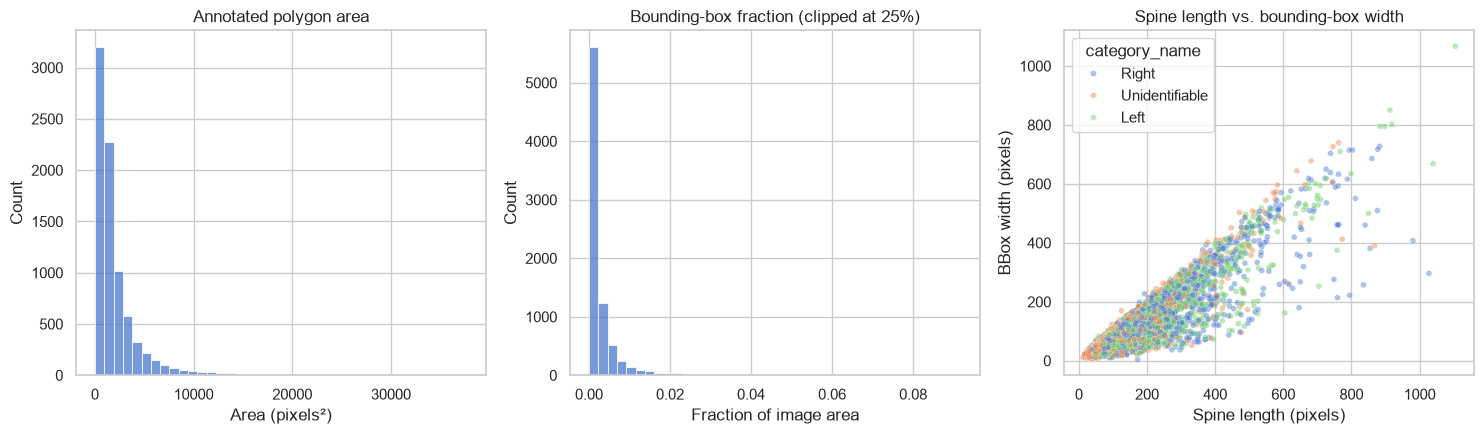

In [30]:
# =============================================
# 5.4. Visualize Gemoetric Data
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Explicitly pass the Series to x to satisfy the type checker
sns.histplot(x=annotation_geometry["area"], bins=40, ax=axes[0])
axes[0].set(title="Annotated polygon area", xlabel="Area (pixels²)")

# Panel 2: Explicitly pass the clipped Series to x
sns.histplot(
    x=annotation_geometry["bbox_area_fraction"].clip(upper=0.25),
    bins=40,
    ax=axes[1],
)
axes[1].set(
    title="Bounding-box fraction (clipped at 25%)",
    xlabel="Fraction of image area",
)

# Panel 3: Correlation scatterplot (data=DataFrame matches structural type stubs)
sns.scatterplot(
    data=annotation_geometry,
    x="spine_length_px",
    y="bbox_width",
    hue="category_name",
    alpha=0.45,
    s=18,
    ax=axes[2],
)
axes[2].set(
    title="Spine length vs. bounding-box width",
    xlabel="Spine length (pixels)",
    ylabel="BBox width (pixels)",
)

plt.tight_layout()
plt.show()


# 6. Image dimensions, formats, dates, and intensity

Inspect every physical train and test image once. Image intensity summaries use a regular spatial subsample (every eighth pixel by default) to keep the EDA responsive while still sampling the full solar disk. These are descriptive summaries, not model normalization parameters.

In [21]:
# =============================================
# 6. Physical image metadata and sampled intensity
# =============================================
INTENSITY_SAMPLE_STEP = 8
FILENAME_PATTERN = re.compile(r"^(?P<timestamp>\d{14})(?P<station>[A-Za-z]{2})\.(?P<extension>jpe?g)$", re.IGNORECASE)

def inspect_image(path: Path, split: str) -> dict:
    match = FILENAME_PATTERN.match(path.name)
    timestamp = datetime.strptime(match.group("timestamp"), "%Y%m%d%H%M%S") if match else pd.NaT
    with Image.open(path) as source:
        image_format = source.format
        original_mode = source.mode
        width, height = source.size
        gray = source.convert("L")
        # Downsample spatially without resizing so summaries include values across the full frame.
        sample = np.asarray(gray)[::INTENSITY_SAMPLE_STEP, ::INTENSITY_SAMPLE_STEP].astype(np.float32)
        quantiles = np.percentile(sample, [1, 5, 25, 50, 75, 95, 99])
        return {
            "split": split, "file_name": path.name, "path": path,
            "file_size_mb": path.stat().st_size / 1024**2,
            "width": width, "height": height, "format": image_format, "original_mode": original_mode,
            "timestamp": timestamp,
            "station_code": match.group("station") if match else None,
            "filename_parses": match is not None,
            "sample_mean": float(sample.mean()), "sample_std": float(sample.std()),
            "p01": quantiles[0], "p05": quantiles[1], "p25": quantiles[2],
            "p50": quantiles[3], "p75": quantiles[4], "p95": quantiles[5], "p99": quantiles[6],
        }

image_rows = [inspect_image(path, "train") for path in train_files]
image_rows.extend(inspect_image(path, "test") for path in test_files)
image_metadata = pd.DataFrame(image_rows)
image_metadata["year"] = image_metadata["timestamp"].dt.year

print("Image metadata by split")
display(image_metadata.groupby("split").agg(
    images=("file_name", "count"), unique_dimensions=("width", lambda values: values.nunique()),
    mean_file_size_mb=("file_size_mb", "mean"), min_file_size_mb=("file_size_mb", "min"),
    max_file_size_mb=("file_size_mb", "max"), modes=("original_mode", lambda values: ", ".join(sorted(values.unique()))),
    formats=("format", lambda values: ", ".join(sorted(map(str, values.unique())))),
    unparsed_filenames=("filename_parses", lambda values: int((~values).sum())),
))
print("Dimension counts")
display(image_metadata.groupby(["split", "width", "height"]).size().rename("images").reset_index())
print("Acquisition year and station distribution (physical files)")
display(image_metadata.groupby(["split", "year"]).size().rename("images").reset_index().head(30))
display(image_metadata.groupby(["split", "station_code"], dropna=False).size().rename("images").reset_index().sort_values(["split", "images"], ascending=[True, False]))

Image metadata by split


,images,unique_dimensions,mean_file_size_mb,min_file_size_mb,max_file_size_mb,modes,formats,unparsed_filenames
split,,,,,,,,
test,180,1,0.7576,0.5494,1.0547,L,JPEG,0
train,707,1,0.7545,0.4589,0.9491,L,JPEG,0


Dimension counts


,split,width,height,images
0,test,2048,2048,180
1,train,2048,2048,707


Acquisition year and station distribution (physical files)


,split,year,images
0,test,2011,24
1,test,2012,23
2,test,2013,23
3,test,2014,22
4,test,2015,17
5,test,2016,22
6,test,2017,19
7,test,2018,4
8,test,2019,2
9,test,2020,3


,split,station_code,images
2,test,Lh,34
0,test,Bh,33
1,test,Ch,33
4,test,Th,27
5,test,Uh,27
3,test,Mh,26
8,train,Lh,127
7,train,Ch,125
9,train,Mh,125
6,train,Bh,118


## 6.1. Image size, acquisition time, and grayscale values

Compare only properties measured from the image files themselves. Train/test differences can reflect how the competition split was assembled; they do not by themselves establish distribution shift or explain model performance.

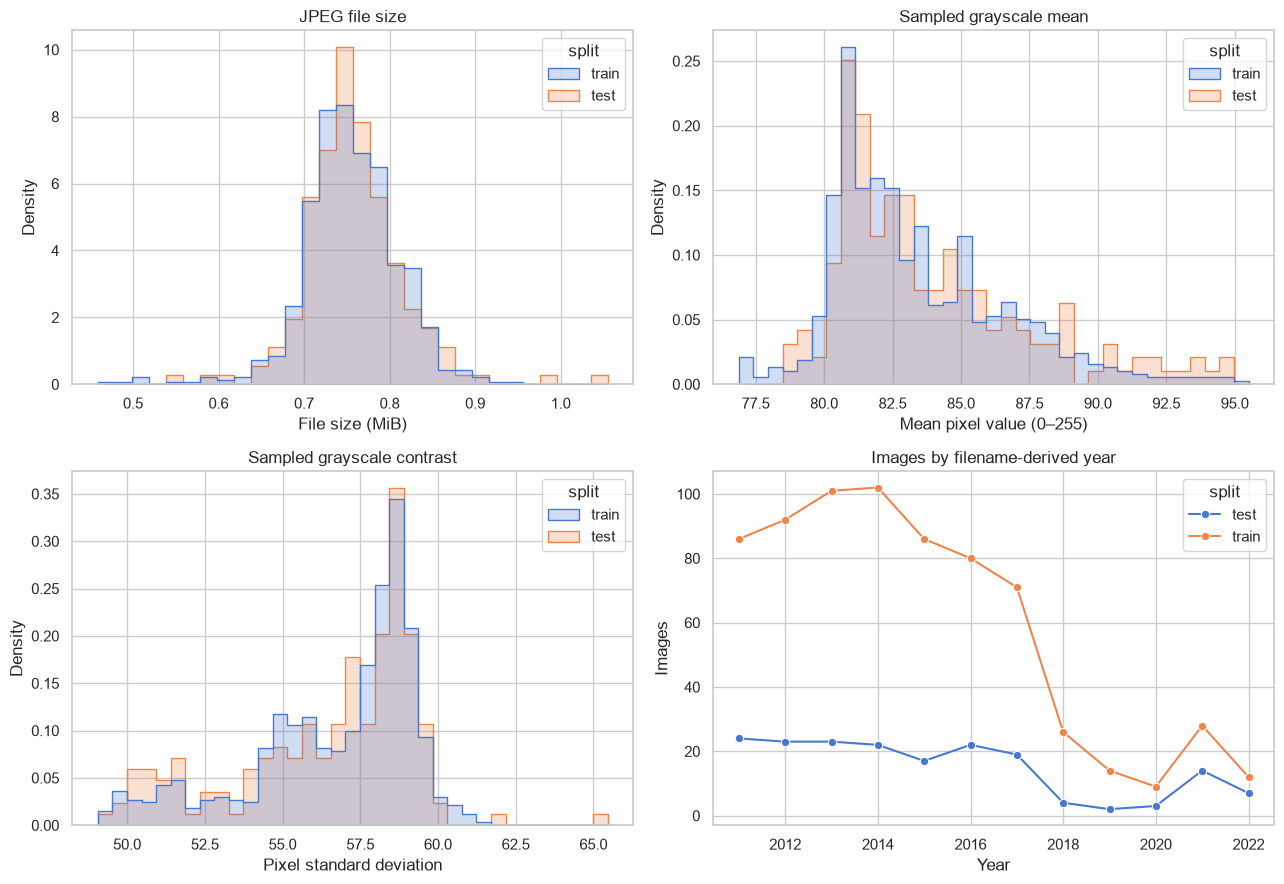

split                 test    train
sample_mean count 180.0000 707.0000
            mean   83.9085  83.3911
            std     3.5600   3.1614
            min    78.7715  76.8859
            25%    81.2699  81.0164
            50%    82.8113  82.5423
            75%    85.5318  85.2132
            max    94.5144  95.5021
sample_std  count 180.0000 707.0000
            mean   56.5012  56.7097
            std     2.9127   2.6419
            min    49.0591  49.1027
            25%    54.8271  55.2215
            50%    57.2878  57.7063
            75%    58.6256  58.6615
            max    65.4524  61.5169
p01         count 180.0000 707.0000
            mean    0.0000   0.0000
            std     0.0000   0.0000
            min     0.0000   0.0000
            25%     0.0000   0.0000
            50%     0.0000   0.0000
            75%     0.0000   0.0000
            max     0.0000   0.0000
p05         count 180.0000 707.0000
            mean    0.0000   0.0000
            std     0.0000   0.0000
            min     0.0000   0.0000
            25%     0.0000   0.0000
            50%     0.0000   0.0000
            75%     0.0000   0.0000
            max     0.0000   0.0000
p50         count 180.0000 707.0000
            mean  110.7639 110.5311
            std     3.7103   3.4637
            min   100.0000  97.0000
            25%   109.0000 109.0000
            50%   111.0000 111.0000
            75%   113.0000 112.0000
            max   121.0000 131.0000
p95         count 180.0000 707.0000
            mean  144.7389 144.6213
            std     2.6179   2.4014
            min   140.0000 136.0000
            25%   143.0000 143.0000
            50%   144.0000 145.0000
            75%   146.0000 146.0000
            max   156.0000 159.0000
p99         count 180.0000 707.0000
            mean  154.7350 154.4259
            std     4.5478   4.0915
            min   146.0000 146.0000
            25%   151.0000 152.0000
            50%   154.0000 154.0000
            75%   157.0000 157.0000
            max   170.0000 174.0000

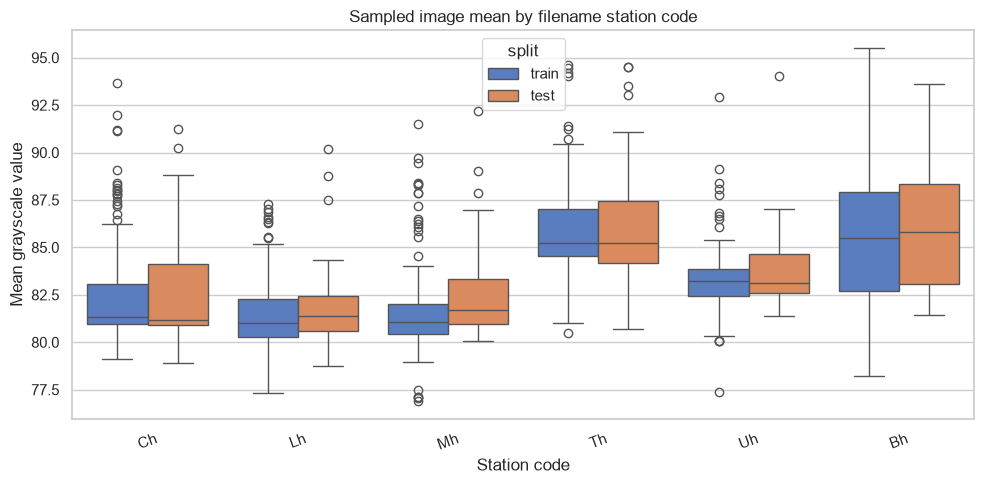

In [22]:
# =============================================
# 6.1. Image distributions
# =============================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(data=image_metadata, x="file_size_mb", hue="split", bins=30, element="step", stat="density", common_norm=False, ax=axes[0, 0])
axes[0, 0].set(title="JPEG file size", xlabel="File size (MiB)")
sns.histplot(data=image_metadata, x="sample_mean", hue="split", bins=35, element="step", stat="density", common_norm=False, ax=axes[0, 1])
axes[0, 1].set(title="Sampled grayscale mean", xlabel="Mean pixel value (0–255)")
sns.histplot(data=image_metadata, x="sample_std", hue="split", bins=35, element="step", stat="density", common_norm=False, ax=axes[1, 0])
axes[1, 0].set(title="Sampled grayscale contrast", xlabel="Pixel standard deviation")
year_counts = image_metadata.dropna(subset=["year"]).groupby(["year", "split"]).size().rename("images").reset_index()
sns.lineplot(data=year_counts, x="year", y="images", hue="split", marker="o", ax=axes[1, 1])
axes[1, 1].set(title="Images by filename-derived year", xlabel="Year", ylabel="Images")
plt.tight_layout()
plt.show()

intensity_summary = image_metadata.groupby("split")[["sample_mean", "sample_std", "p01", "p05", "p50", "p95", "p99"]].describe().T
display(intensity_summary)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=image_metadata, x="station_code", y="sample_mean", hue="split", ax=ax)
ax.set(title="Sampled image mean by filename station code", xlabel="Station code", ylabel="Mean grayscale value")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# 7. Visual audit: images with polygon and spine overlays

Render several deterministically selected training records with their annotations. Each panel displays the physical JPEG, category-colored polygon outlines, and the provided spine path. The selector samples across annotation-record instance counts; if a filename has multiple records, the title makes the record ID explicit.

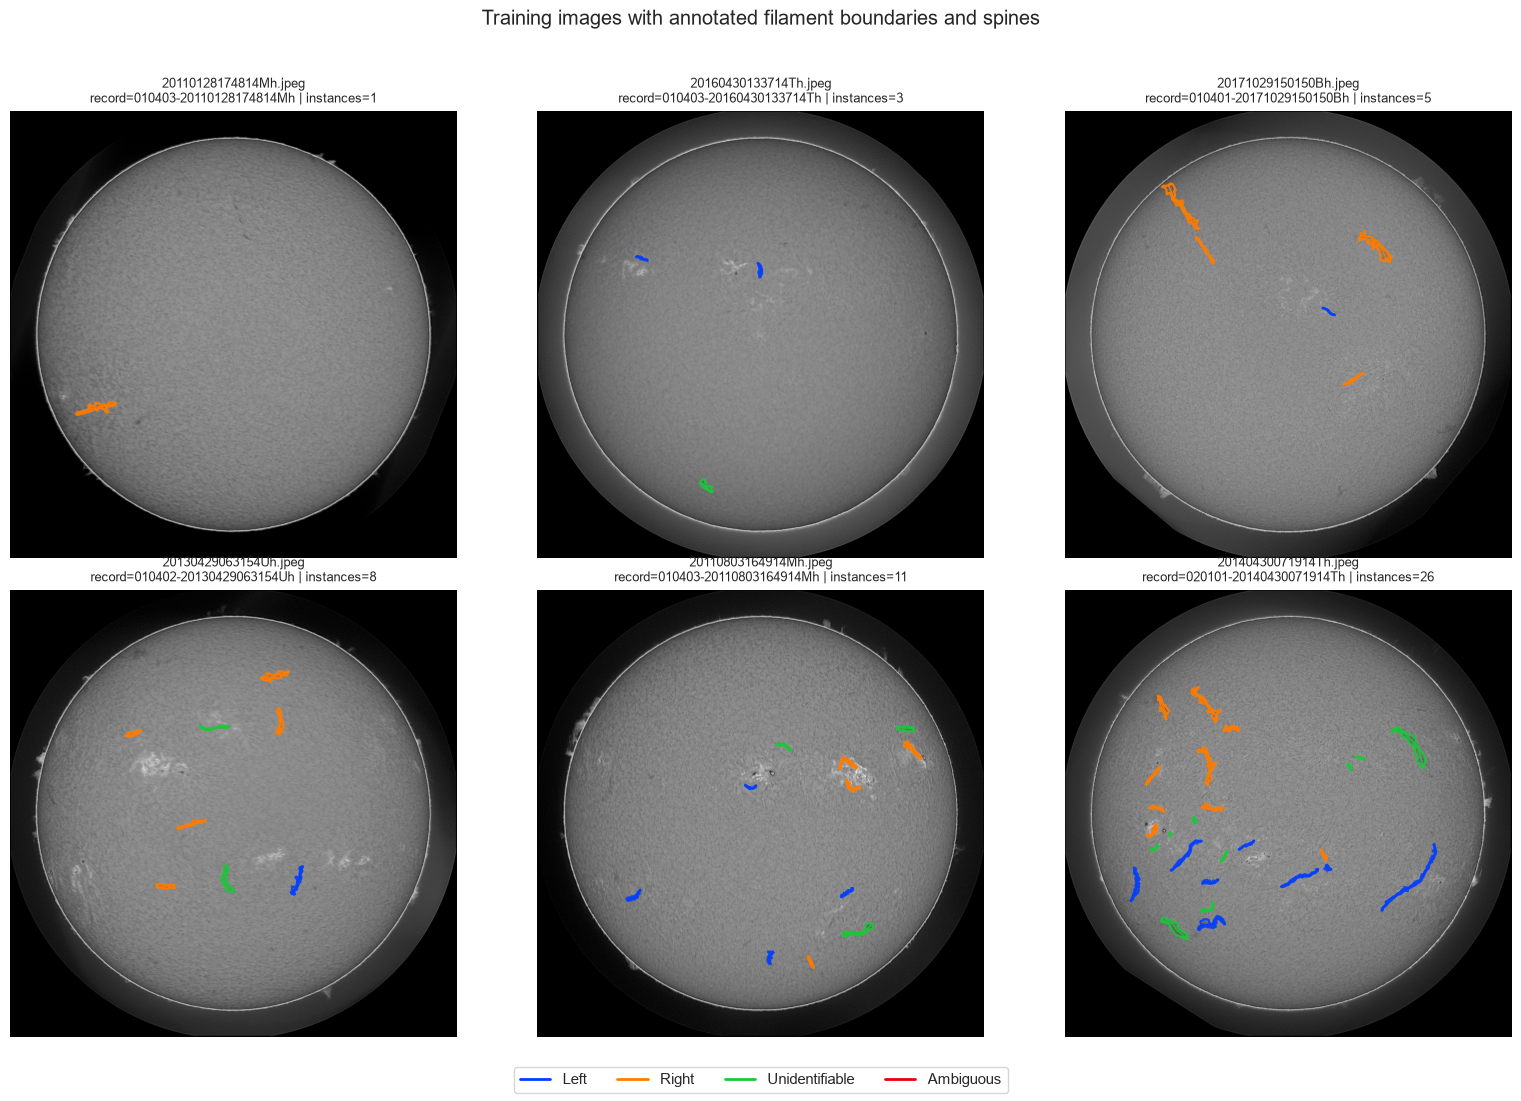

In [23]:
# =============================================
# 7. Annotation overlays
# =============================================
annotations_by_image = {}
for annotation in annotations_data["annotations"]:
    annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)
image_row_by_id = images_df.set_index("id").to_dict("index")
category_colors = {
    name: color for name, color in zip(categories_df["name"], sns.color_palette("bright", n_colors=max(1, len(categories_df))))
}

record_counts_for_examples = record_counts.sort_values(["instance_count", "file_name"])
if len(record_counts_for_examples) > 0:
    positions = np.linspace(0, len(record_counts_for_examples) - 1, min(6, len(record_counts_for_examples))).round().astype(int)
    example_records = record_counts_for_examples.iloc[positions].drop_duplicates("id")
else:
    example_records = record_counts_for_examples

n_examples = len(example_records)
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = np.asarray(axes).ravel()
for ax, (_, record) in zip(axes, example_records.iterrows()):
    image_record = image_row_by_id[record["id"]]
    image_path = TRAIN_IMAGES_DIR / image_record["file_name"]
    with Image.open(image_path) as source:
        ax.imshow(source.convert("L"), cmap="gray", vmin=0, vmax=255)
    for annotation in annotations_by_image.get(record["id"], []):
        category_name = category_name_by_id.get(annotation["category_id"], "Unknown")
        color = category_colors.get(category_name, "red")
        segmentation = annotation.get("segmentation") or []
        if segmentation and isinstance(segmentation[0], list) and len(segmentation[0]) >= 6:
            polygon = np.asarray(segmentation[0], dtype=float).reshape(-1, 2)
            ax.add_patch(PolygonPatch(polygon, closed=True, fill=False, edgecolor=color, linewidth=1.6, alpha=.9))
        spine = np.asarray(annotation.get("spine") or [], dtype=float)
        if len(spine) >= 4:
            spine = spine.reshape(-1, 2)
            ax.plot(spine[:, 0], spine[:, 1], color=color, linewidth=1.0, alpha=.95)
    ax.set_title(f"{image_record['file_name']}\nrecord={record['id']} | instances={record['instance_count']}", fontsize=9)
    ax.axis("off")
for ax in axes[n_examples:]:
    ax.axis("off")
legend_handles = [plt.Line2D([0], [0], color=color, lw=2, label=name) for name, color in category_colors.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=max(1, len(legend_handles)))
fig.suptitle("Training images with annotated filament boundaries and spines", y=.99)
plt.tight_layout(rect=[0, .04, 1, .97])
plt.show()

## 7.1. Polygon-only mask preview

A rasterized mask preview is useful for checking that polygon coordinates align with the source image. The example below draws one record's instances into a category-coded mask at the source resolution, then shows the image and mask side by side.

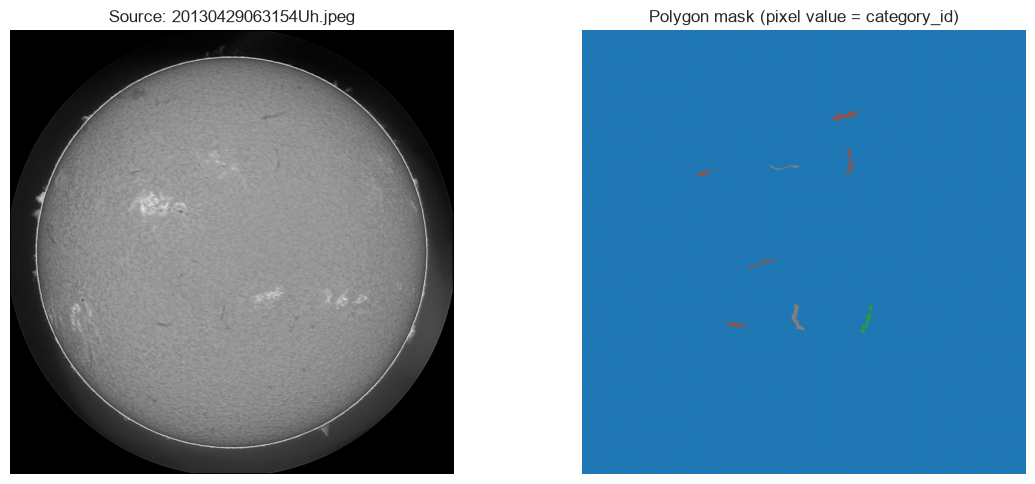

In [24]:
# =============================================
# 7.1. Rasterized mask sanity preview
# =============================================
if len(example_records):
    example = example_records.iloc[len(example_records) // 2]
    image_record = image_row_by_id[example["id"]]
    image_path = TRAIN_IMAGES_DIR / image_record["file_name"]
    with Image.open(image_path) as source:
        gray_image = source.convert("L")
        mask = Image.new("L", gray_image.size, color=0)
        draw = ImageDraw.Draw(mask)
        for annotation in annotations_by_image.get(example["id"], []):
            segmentation = annotation.get("segmentation") or []
            if not segmentation or not isinstance(segmentation[0], list):
                continue
            points = np.asarray(segmentation[0], dtype=float).reshape(-1, 2)
            category_id = int(annotation["category_id"])
            draw.polygon([tuple(point) for point in points], fill=category_id)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(gray_image, cmap="gray")
    axes[0].set_title(f"Source: {image_record['file_name']}")
    axes[1].imshow(mask, cmap="tab10", vmin=0, vmax=max(4, int(categories_df["id"].max())))
    axes[1].set_title("Polygon mask (pixel value = category_id)")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No annotation image records available for mask preview.")

# 8. Findings and EDA handoff

The summary below is calculated from the loaded files, so it remains accurate if the dataset version or path changes. Treat the findings as descriptive dataset diagnostics. They are not model results and do not establish the cause of any future validation behavior.

In [25]:
# =============================================
# 8. Compact dynamic findings
# =============================================
duplicate_filename_count = int(images_df["file_name"].duplicated().sum())
extra_records = int(len(images_df) - images_df["file_name"].nunique())
most_common_category = category_counts.sort_values("instances", ascending=False).iloc[0]
category_coverage = category_image_summary.sort_values("image_records_with_class", ascending=False)
valid_polygon_count = int((
    annotation_geometry["polygon_even_coordinate_count"]
    & annotation_geometry["polygon_has_three_vertices"]
    & annotation_geometry["polygon_in_bounds"]
).sum())

print("KEY FINDINGS")
print(f"• Physical image files: {len(train_files):,} train and {len(test_files):,} unlabeled test.")
print(f"• Training annotations: {len(images_df):,} JSON image records map to {images_df['file_name'].nunique():,} distinct training filenames.")
print(f"• {duplicate_filename_count:,} JSON image records are additional records beyond one per filename; {duplicate_file_summary.shape[0]:,} filenames appear more than once.")
print(f"• The JSON contains {len(annotations_df):,} filament instances across {annotations_df['image_id'].nunique():,} annotated image records.")
print(f"• Most frequent instance category: {most_common_category['category_name']} ({int(most_common_category['instances']):,}; {most_common_category['instance_percent']:.1f}% of instances).")
print(f"• Polygon structure/bounds checks pass for {valid_polygon_count:,}/{len(annotation_geometry):,} annotation instances.")
print(f"• All physical-image intensity summaries use a {INTENSITY_SAMPLE_STEP}× spatial step in each dimension.")
print("• Split validation by physical filename to prevent repeated-image leakage.")

print("\nRecommended next notebook steps")
print("1. Decide whether separate records for the same filename should be modeled separately or reconciled before training.")
print("2. Build validation folds grouped by physical filename; consider acquisition time/station only after inspecting group sizes.")
print("3. Keep preprocessing grayscale and preserve polygon/spine coordinates through every resize or crop transform.")
print("4. Inspect rare categories and thin structures at full resolution before choosing mask rasterization and augmentation settings.")

KEY FINDINGS
• Physical image files: 707 train and 180 unlabeled test.
• Training annotations: 1,154 JSON image records map to 707 distinct training filenames.
• 447 JSON image records are additional records beyond one per filename; 296 filenames appear more than once.
• The JSON contains 8,199 filament instances across 1,154 annotated image records.
• Most frequent instance category: Unidentifiable (3,074; 37.5% of instances).
• Polygon structure/bounds checks pass for 8,199/8,199 annotation instances.
• All physical-image intensity summaries use a 8× spatial step in each dimension.
• Split validation by physical filename to prevent repeated-image leakage.

Recommended next notebook steps
1. Decide whether separate records for the same filename should be modeled separately or reconciled before training.
2. Build validation folds grouped by physical filename; consider acquisition time/station only after inspecting group sizes.
3. Keep preprocessing grayscale and preserve polygon/spine 

## 9. Scope and caveats

- The EDA reads image properties from files and target labels from the provided JSON only.
- Category names and IDs come from the JSON. A category with no annotations remains visible in summaries with a count of zero.
- Annotation-record counts and physical image-file counts are reported separately because filenames repeat in the JSON.
- The intensity statistics are subsampled summaries and should not be substituted for training-time normalization decisions.
- Polygon areas can overlap, so summing instance areas is not the same as measuring unique filament coverage of the solar disk.
- No model training, inference, or test-set label inspection is performed in this notebook.